# AMP Testing
Approximate Message Passing experiments (random matrix theory).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

AMP method comes from statistical physics and goes back to mean field theory to describe spin glasses. In 2003 it was used to decode mobile phone signals, and brough into statistics in 2009 for compressed senssing named "AMP" and show state evolution predicts its accuracy. Now used to calculate limits on what can be learned from a data set.

We observe

$$
A = \frac{\lambda}{n}\, v v^{\top} + W \in \mathbb{R}^{n \times n},
$$

where

- $v \in \{-1, +1\}^n$ is the unknown signal, with $v_i \overset{\text{iid}}{\sim} \mathrm{Unif}\{-1, +1\}$, so $\|v\|^2 = n$
- $W$ is symmetric Gaussian noise, independent of $v$, with $W_{ij} \sim N(0, 1/n)$ for $i < j$ and $W_{ii} \sim N(0, 2/n)$
- $\lambda > 0$ is the signal strength, fixed as $n \to \infty$

**Goal:** estimate $v$ from $A$.

**Performance measure:** the squared overlap between an estimate $\hat v$ and the truth,

$$
\frac{\langle \hat v, v \rangle^2}{\|\hat v\|^2 \, \|v\|^2} \in [0, 1].
$$

So we assume our true value V, has finite entries and further finite variance

## Step 1: Generate the model and check the noise spectrum - Wigner's semicircle law


Before estimating anything, check that $W$ is scaled correctly. With entries of variance $1/n$,
the eigenvalues of $W$ should fill the semicircle law on $[-2, 2]$:

$$
\rho(x) = \frac{1}{2\pi}\sqrt{4 - x^2}, \qquad |x| \le 2.
$$

Adding the spike should leave this bulk unchanged. When $\lambda > 1$, one eigenvalue should
separate from the bulk and sit near $\lambda + 1/\lambda$.

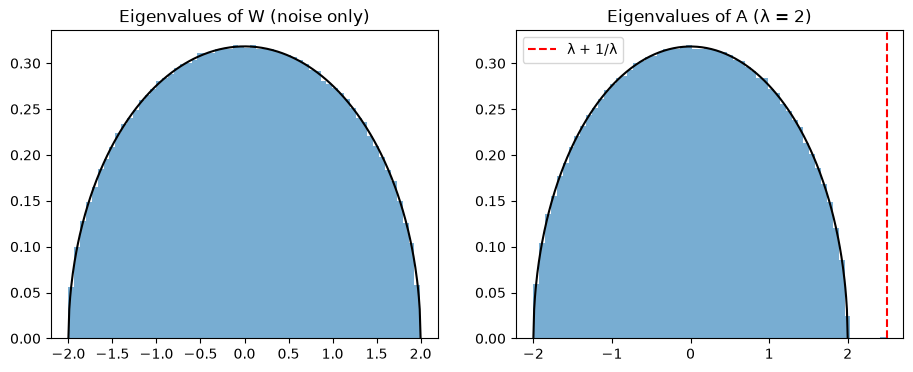

top eigenvalue of A: 2.4823919576747957  theory: 2.5


In [16]:
n = 10000
rng = np.random.default_rng(0)
def sample_model(lam,n,rng):
    V = rng.choice([-1.0,1.0], n)
    G = rng.normal(size=(n,n))
    # We are calculating a symetric matrix
    # Must scale it as each diagonal entry is the sum of 2 independet N(0,1) 
    # Now as values are in [-2,2] its we must sqrt it to get back to normal values.
    # As we know that scaling a matrix scales its eigenvalues,
    # A larger matrix has larger eigen values as well, if entries stay the same,
    # Seen in symmetric matrix where the sum of eignvalues, is the sum of the sum of squared entries.
    # Simple maths as we have N^2 entries, n eigien values each value roughly root n.
    W = ( G + G.T ) / np.sqrt(2*n)
    A = (lam / n) * np.outer(V,V) + W
    return A,V,W

lam = 2

A,V,W = sample_model(lam,n,rng)

eig_W = np.linalg.eigvalsh(W)
eig_A = np.linalg.eigvalsh(A)

x = np.linspace(-2,2,400)
semicircle = np.sqrt(4-x**2) / (2* np.pi)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(eig_W, bins=60, density=True, alpha=0.6)
ax[0].plot(x, semicircle, "k")
ax[0].set_title("Eigenvalues of W (noise only)")

ax[1].hist(eig_A, bins=60, density=True, alpha=0.6)
ax[1].plot(x, semicircle, "k")
ax[1].axvline(lam + 1 / lam, color="r", ls="--", label="λ + 1/λ")
ax[1].set_title(f"Eigenvalues of A (λ = {lam})")
ax[1].legend()
plt.show()

print("top eigenvalue of A:", eig_A[-1], " theory:", lam + 1 / lam)

The eigenvalues of a large symmetric random matrix W, with entries of variance 1/n will fill [-2,2] with density seen above. And if true noise occurs, then As eigen value will be lambda + 1/lambda

### BBP transition: the top eigenvalue across λ

A single value of λ only shows what happens at that one signal strength. For a strong signal
(λ > 1), one eigenvalue breaks free of the noise and sits at λ + 1/λ. For a weak signal
(λ ≤ 1), the signal is lost in the noise and the top eigenvalue stays at the noise edge, 2.

To see the transition between these two behaviours, we sweep λ and record the top eigenvalue
of $A$ each time. Theory (Baik, Ben Arous and Péché) predicts


## Recovering v from this top eigien vector 

https://www.youtube.com/watch?v=FD4DeN81ODY

Using PCA is useful, this returning the largest eignvector belonging to the largest eigenvalue. This being called the top or leading eigen vector. 

PCAs theory starts at project as xprime being the amount of information of x that is 